# Equivariance Showcase — the guarantee, visualized

This project's whole claim (CLAUDE.md §1, §8): identical molecules in different coordinate
frames must give **identical** outputs — energy is invariant, Wannier centers transform *with*
the molecule. This is enforced **by the architecture** (EGNN), not by data augmentation.

The strongest demonstration: it holds on an **untrained** network. Random weights already
satisfy it, because the symmetry is structural. Below we rotate / translate / mirror / permute
a methane molecule and watch the outputs track the transform exactly.

In [1]:
%matplotlib inline
import demo_utils  # noqa: F401 — puts the repo root on sys.path
import numpy as np
import matplotlib.pyplot as plt
from demo_utils import demo_molecule, init_model, plot_molecule
from symmetry import transforms as T

z, pos = demo_molecule()
model, params, apply = init_model()          # random weights — NO training

base = apply(params, z, pos)
base_centers = np.asarray(base["wannier"]["centers"])   # [spin, slot, 3]
print("energy (eV):", float(base["energy"]))
print("center slots per spin:", base_centers.shape[1])

energy (eV): 1.6076881885528564
center slots per spin: 8


## Rotation → energy invariant, centers rotate by R

energy drift = 4.77e-07 eV     center drift (vs R·centers) = 2.07e-07 Å


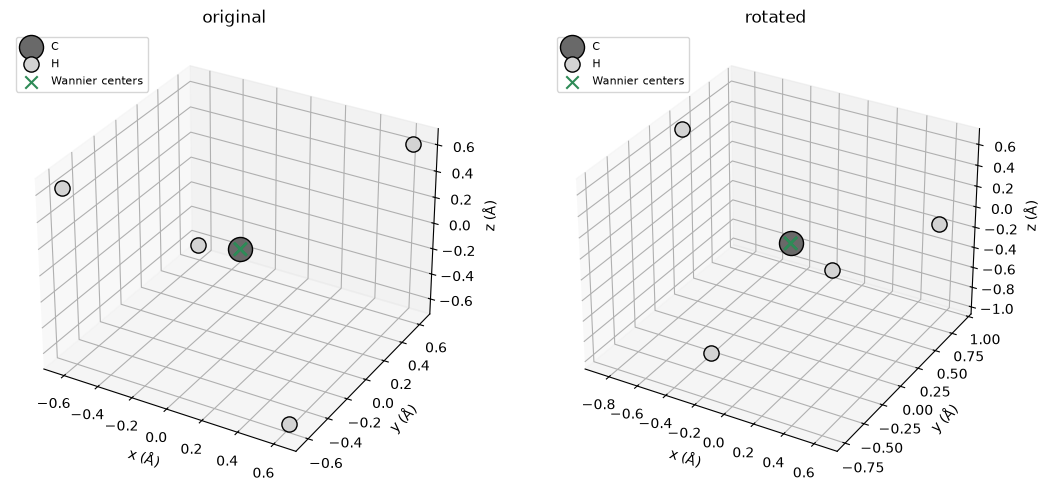

In [2]:
R = T.random_rotation(seed=1)
rot = apply(params, z, np.asarray(T.rotate(pos, R)))
e_drift = abs(float(rot["energy"]) - float(base["energy"]))
c_drift = float(np.max(np.abs(np.asarray(rot["wannier"]["centers"]) - base_centers @ R.T)))
print(f"energy drift = {e_drift:.2e} eV     center drift (vs R·centers) = {c_drift:.2e} Å")
assert e_drift < 1e-6 and c_drift < 1e-6, "equivariance broken!"

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(121, projection="3d")
plot_molecule(ax1, z, pos, base_centers[0], title="original")
ax2 = fig.add_subplot(122, projection="3d")
plot_molecule(ax2, z, T.rotate(pos, R), np.asarray(rot["wannier"]["centers"])[0],
              title="rotated")
plt.tight_layout(); plt.show()

## Translation → energy invariant, centers shift by t

In [3]:
t = np.array([1.5, -0.8, 0.4])
tr = apply(params, z, np.asarray(T.translate(pos, t)))
e_drift = abs(float(tr["energy"]) - float(base["energy"]))
c_drift = float(np.max(np.abs(np.asarray(tr["wannier"]["centers"]) - (base_centers + t))))
print(f"energy drift = {e_drift:.2e} eV     center drift (vs centers + t) = {c_drift:.2e} Å")
assert e_drift < 1e-6 and c_drift < 1e-6

energy drift = 8.34e-07 eV     center drift (vs centers + t) = 2.33e-07 Å


## Mirror → energy invariant, centers reflect (architecture has no chiral features, §8)

In [4]:
rf = apply(params, z, np.asarray(T.mirror(pos, axis=1)))
M = np.eye(3); M[1, 1] = -1.0
e_drift = abs(float(rf["energy"]) - float(base["energy"]))
c_drift = float(np.max(np.abs(np.asarray(rf["wannier"]["centers"]) - base_centers @ M.T)))
print(f"energy drift = {e_drift:.2e} eV     center drift (vs M·centers) = {c_drift:.2e} Å")
assert e_drift < 1e-6 and c_drift < 1e-6

energy drift = 0.00e+00 eV     center drift (vs M·centers) = 0.00e+00 Å


## Permutation → all outputs unchanged (unordered atoms / unordered center set)

In [5]:
perm = T.permutation(len(z), seed=2)
pm = apply(params, np.asarray(z)[perm], np.asarray(pos)[perm])
e_drift = abs(float(pm["energy"]) - float(base["energy"]))
set_drift = float(np.max(np.abs(np.sort(np.asarray(pm["wannier"]["centers"]), axis=None)
                                - np.sort(base_centers, axis=None))))
print(f"energy drift = {e_drift:.2e} eV     center-set drift = {set_drift:.2e} Å")
assert e_drift < 1e-6 and set_drift < 1e-6

energy drift = 0.00e+00 eV     center-set drift = 1.35e-07 Å


### Takeaway

Every drift is ~machine-epsilon on an **untrained** model. The symmetry is not learned and not
approximated — it is a property of the EGNN construction (invariant messages, coordinate
updates that only ever scale relative vectors by invariant weights). That is the entire point
of the design.